# VisDrone Dataset Visualization

This notebook gives a compact view of split sizes and class balance across the local VisDrone detection dataset.

In [ ]:
from collections import Counter
import random
from pathlib import Path
import os
import logging

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from src.utils import change_file_type

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")


In [56]:
logging.basicConfig(level=logging.INFO, filename="a.log",filemode="a")

logging.debug("A DEBUG Message")
logging.info("An INFO")
logging.warning("A WARNING")
logging.error("An ERROR")
logging.critical("A message of CRITICAL severity")

In [3]:
DATA_DIR = Path("./data")

CLASS_NAMES = {
    0: "ignored_regions",
    1: "pedestrian",
    2: "people",
    3: "bicycle",
    4: "car",
    5: "van",
    6: "truck",
    7: "tricycle",
    8: "awning_tricycle",
    9: "bus",
    10: "motor",
    11: "others",
}

SAMPLE_GRID_SHAPE = (2, 4)


def iter_label_rows(label_path: Path):
    with label_path.open("r", encoding="utf-8") as handle:
        for line in handle:
            stripped = line.strip()
            if not stripped:
                continue

            yield tuple(map(float, stripped.split()))


def get_image_size(image_path: Path) -> tuple[int, int]:
    with Image.open(image_path) as image:
        return image.size


def iter_split_dirs(data_dir: Path):
    return sorted(path for path in data_dir.iterdir() if path.is_dir())


def visualize_random_samples(split_dir: str | Path, values: list[int] | None = None, sample_size: int = 8) -> None:
    split_dir = Path(split_dir)
    image_dir = split_dir / "images"
    label_dir = split_dir / "labels"
    selected_classes = set(CLASS_NAMES if values is None else values)

    invalid_classes = sorted(class_id for class_id in selected_classes if class_id not in CLASS_NAMES)
    if invalid_classes:
        raise ValueError(f"Unknown class ids: {invalid_classes}")

    candidates = []
    for image_path in sorted(image_dir.glob("*.jpg")):
        label_path = label_dir / f"{image_path.stem}.txt"
        if not label_path.exists():
            continue

        matching_boxes = []
        for class_id, x_center, y_center, width, height in iter_label_rows(label_path):
            class_id = int(class_id)
            if class_id not in selected_classes:
                continue

            matching_boxes.append((class_id, x_center, y_center, width, height))

        if matching_boxes:
            candidates.append((image_path, matching_boxes))

    if not candidates:
        raise ValueError(f"No images with classes {sorted(selected_classes)} were found in {split_dir}.")

    sample_count = min(sample_size, len(candidates))
    sampled_items = random.sample(candidates, k=sample_count)

    fig, axes = plt.subplots(*SAMPLE_GRID_SHAPE, figsize=(20, 10))
    axes = axes.flatten()

    for axis, (image_path, boxes) in zip(axes, sampled_items):
        with Image.open(image_path) as image:
            image = image.convert("RGB")
            image_width, image_height = image.size
            axis.imshow(image)

        for class_id, x_center, y_center, width, height in boxes:
            box_width = width * image_width
            box_height = height * image_height
            x_min = (x_center * image_width) - box_width / 2
            y_min = (y_center * image_height) - box_height / 2

            rectangle = patches.Rectangle(
                (x_min, y_min),
                box_width,
                box_height,
                linewidth=2,
                edgecolor="lime",
                facecolor="none",
            )
            axis.add_patch(rectangle)
            axis.text(
                x_min,
                max(y_min - 4, 0),
                CLASS_NAMES[class_id],
                color="white",
                fontsize=9,
                bbox={"facecolor": "black", "alpha": 0.7, "pad": 2},
            )

        axis.set_title(image_path.name)
        axis.axis("off")

    for axis in axes[sample_count:]:
        axis.axis("off")

    class_names = [CLASS_NAMES[class_id] for class_id in sorted(selected_classes)]
    fig.suptitle(f"Random samples from {split_dir.name} | classes: {', '.join(class_names)}", fontsize=14)
    fig.tight_layout()
    plt.show()


def summarize_split(split_dir: Path) -> tuple[dict, Counter]:
    image_count = len(list((split_dir / "images").glob("*.jpg")))
    label_files = sorted((split_dir / "labels").glob("*.txt"))
    class_counts = Counter({class_id: 0 for class_id in CLASS_NAMES})
    box_count = 0

    for label_path in label_files:
        for row in iter_label_rows(label_path):
            class_id = int(row[0])
            class_counts[class_id] += 1
            box_count += 1

    summary = {
        "split": split_dir.name,
        "images": image_count,
        "label_files": len(label_files),
        "boxes": box_count,
        "avg_boxes_per_image": box_count / image_count if image_count else 0,
    }
    return summary, class_counts


split_dirs = iter_split_dirs(DATA_DIR)
split_summaries = []
class_distributions = {}

for split_dir in split_dirs:
    summary, counts = summarize_split(split_dir)
    split_summaries.append(summary)
    class_distributions[split_dir.name] = counts

summary_df = pd.DataFrame(split_summaries).sort_values("images", ascending=False)
summary_df["image_share"] = summary_df["images"] / summary_df["images"].sum()
summary_df


,split,images,label_files,boxes,avg_boxes_per_image,image_share
1,VisDrone2019-DET-train,6471,6471,353550,54.64,0.75
0,VisDrone2019-DET-test-dev,1610,1610,77547,48.17,0.19
2,VisDrone2019-DET-val,548,548,40169,73.30,0.06


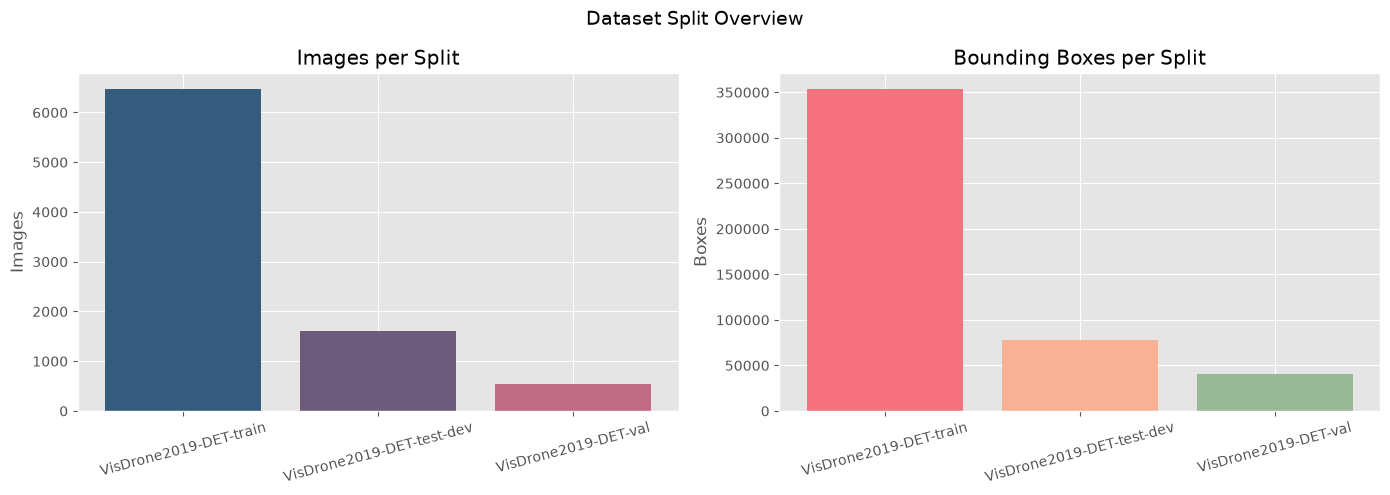

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_specs = [
    ("images", "Images per Split", "Images", ["#355C7D", "#6C5B7B", "#C06C84"]),
    ("boxes", "Bounding Boxes per Split", "Boxes", ["#F67280", "#F8B195", "#99B898"]),
]

for axis, (column, title, ylabel, colors) in zip(axes, plot_specs):
    axis.bar(summary_df["split"], summary_df[column], color=colors)
    axis.set_title(title)
    axis.set_ylabel(ylabel)
    axis.tick_params(axis="x", rotation=15)

fig.suptitle("Dataset Split Overview", fontsize=14)
fig.tight_layout()
plt.show()


In [5]:
class_df = pd.DataFrame(class_distributions).rename(index=CLASS_NAMES)
class_df["total"] = class_df.sum(axis=1)
class_df = class_df.sort_values("total", ascending=True)
class_df


,VisDrone2019-DET-test-dev,VisDrone2019-DET-train,VisDrone2019-DET-val,total
others,265,1532,32,1829
awning_tricycle,599,3246,532,4377
tricycle,530,4812,1045,6387
bus,2940,5926,251,9117
ignored_regions,2180,8813,1378,12371
bicycle,1302,10480,1287,13069
truck,2659,12875,750,16284
van,5771,24956,1975,32702
people,6376,27059,5125,38560
motor,5845,29647,4886,40378


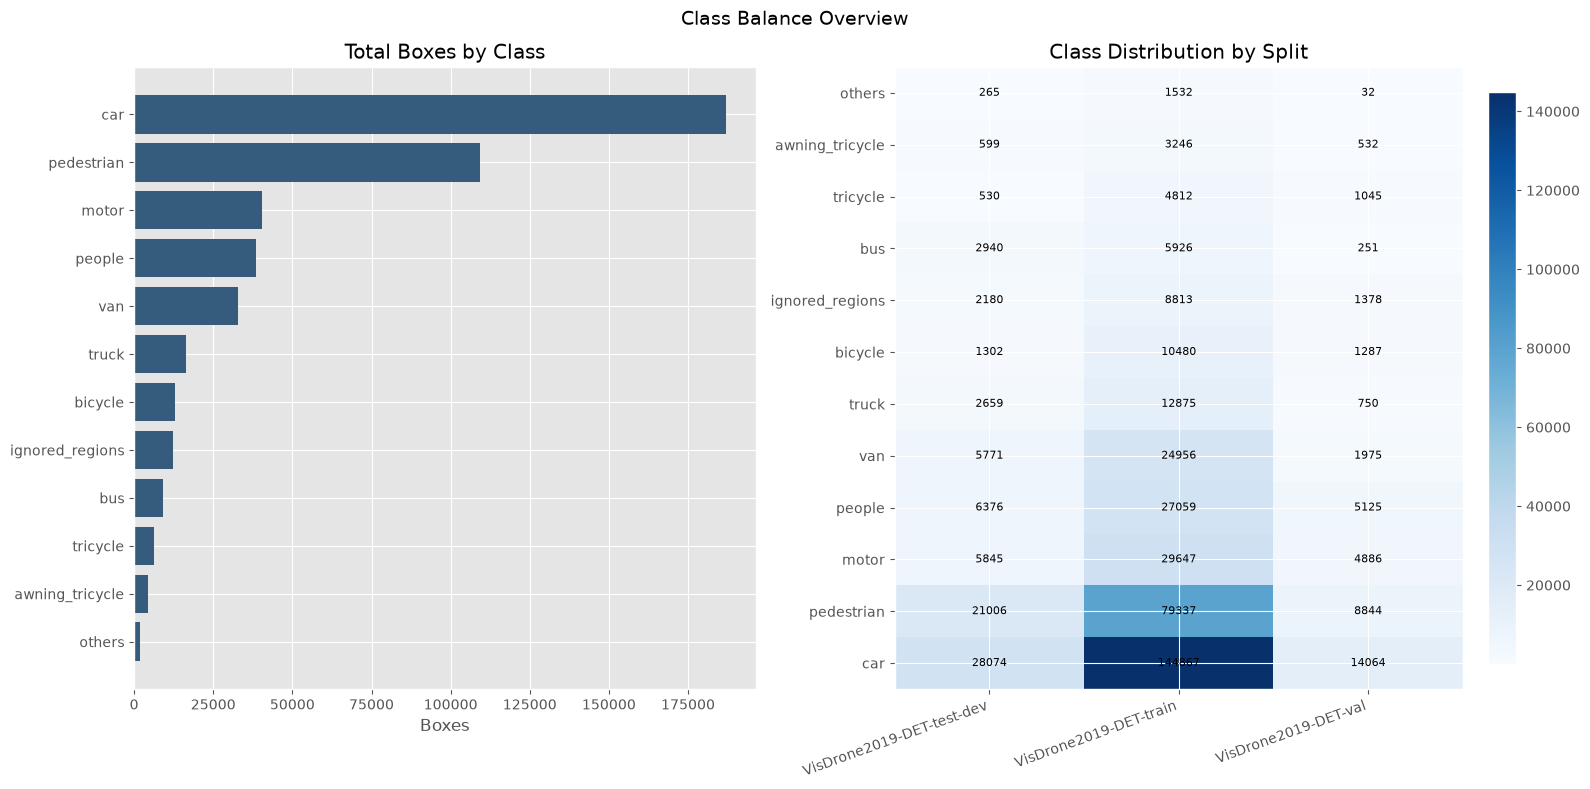

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].barh(class_df.index, class_df["total"], color="#355C7D")
axes[0].set_title("Total Boxes by Class")
axes[0].set_xlabel("Boxes")

heatmap_values = class_df.drop(columns="total")
image = axes[1].imshow(heatmap_values, aspect="auto", cmap="Blues")
axes[1].set_title("Class Distribution by Split")
axes[1].set_xticks(range(len(heatmap_values.columns)))
axes[1].set_xticklabels(heatmap_values.columns, rotation=20, ha="right")
axes[1].set_yticks(range(len(heatmap_values.index)))
axes[1].set_yticklabels(heatmap_values.index)

for row_idx, row_name in enumerate(heatmap_values.index):
    for col_idx, col_name in enumerate(heatmap_values.columns):
        value = int(heatmap_values.loc[row_name, col_name])
        axes[1].text(col_idx, row_idx, f"{value}", ha="center", va="center", color="black", fontsize=8)

fig.colorbar(image, ax=axes[1], fraction=0.046, pad=0.04)
fig.suptitle("Class Balance Overview", fontsize=14)
fig.tight_layout()
plt.show()


In [7]:
bbox_rows = []

for split_dir in split_dirs:
    split_name = split_dir.name

    for label_path in sorted((split_dir / "labels").glob("*.txt")):
        image_path = change_file_type(label_path)
        image_width, image_height = get_image_size(image_path)

        for class_id, _, _, norm_width, norm_height in iter_label_rows(label_path):
            width = norm_width * image_width
            height = norm_height * image_height

            bbox_rows.append(
                {
                    "split": split_name,
                    "class_name": CLASS_NAMES[int(class_id)],
                    "width": width,
                    "height": height,
                    "area": width * height,
                    "aspect_ratio": width / height if height else 0,
                }
            )

bbox_df = pd.DataFrame(bbox_rows)

bbox_df.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])


,width,height,area,aspect_ratio
count,"471,266.00","471,266.00","471,266.00","471,266.00"
mean,37.19,36.19,"2,286.28",1.09
std,40.18,32.93,"6,342.56",0.70
min,2.00,0.00,0.00,0.00
10%,7.00,10.00,90.00,0.41
25%,13.00,16.00,224.01,0.56
50%,24.00,26.00,637.99,0.89
75%,47.00,44.00,"1,886.01",1.44
90%,82.00,72.00,"5,291.98",2.10
max,"1,424.00",790.00,"355,432.35",31.27


/tmp/ipykernel_18368/896483329.py:20: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1, 1].boxplot(boxplot_data, tick_labels=split_order, vert=True)


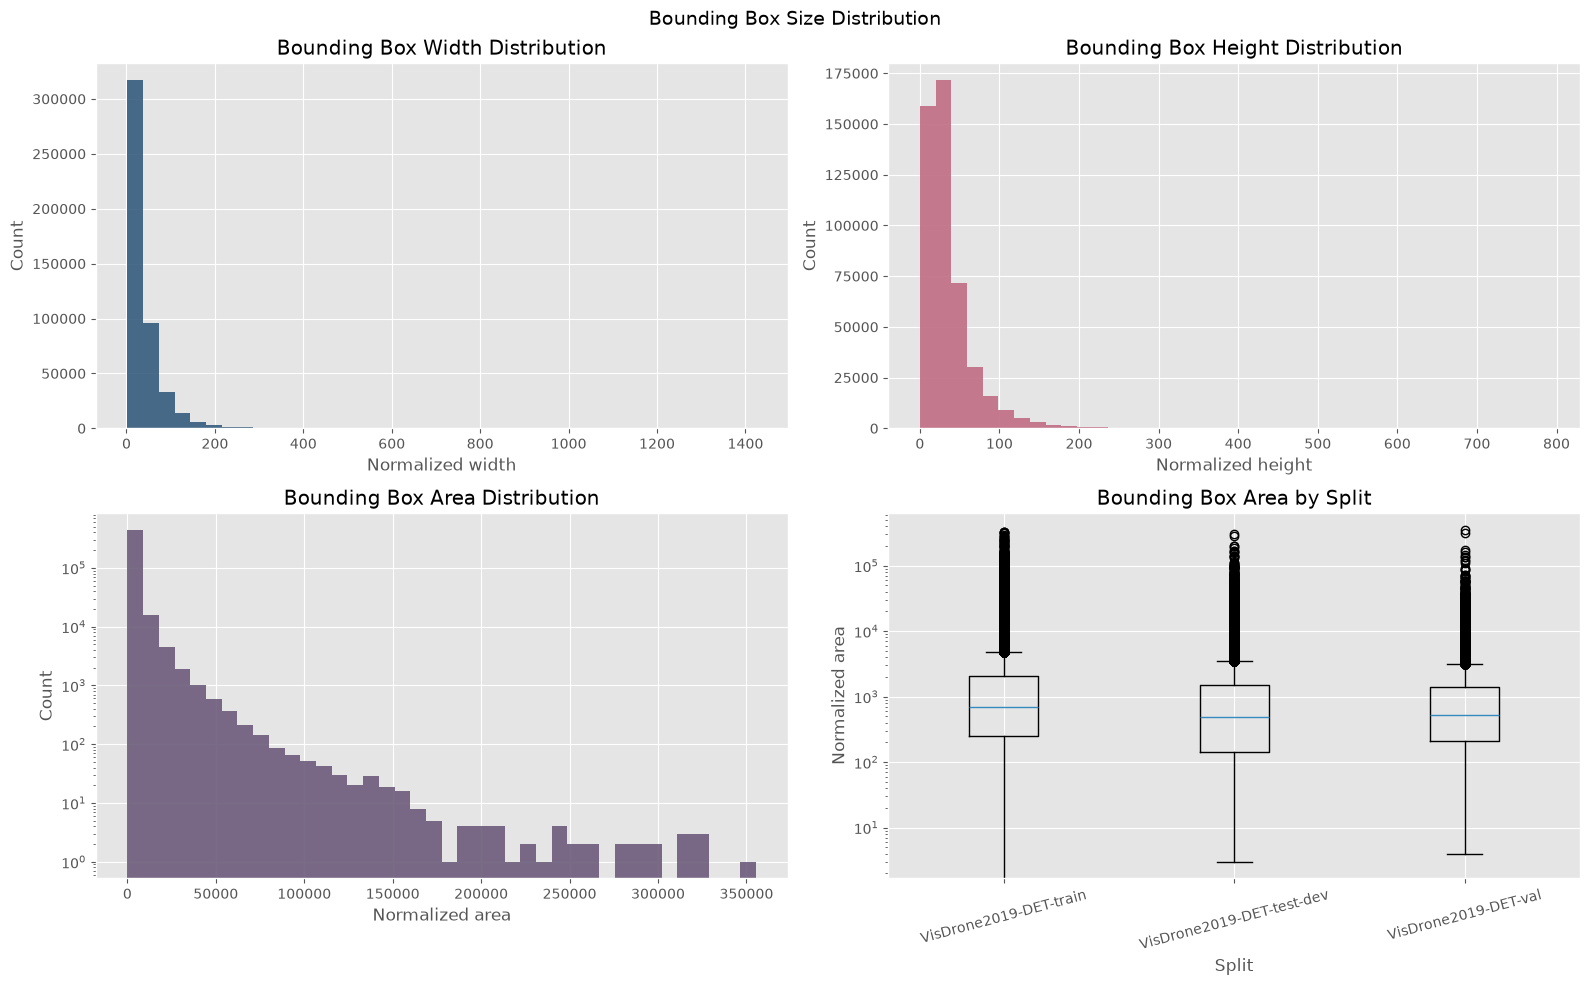

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

histogram_specs = [
    ((0, 0), "width", "Bounding Box Width Distribution", "Normalized width", "#355C7D"),
    ((0, 1), "height", "Bounding Box Height Distribution", "Normalized height", "#C06C84"),
    ((1, 0), "area", "Bounding Box Area Distribution", "Normalized area", "#6C5B7B"),
]

for (row_idx, col_idx), column, title, xlabel, color in histogram_specs:
    axis = axes[row_idx, col_idx]
    axis.hist(bbox_df[column], bins=40, color=color, alpha=0.9)
    axis.set_title(title)
    axis.set_xlabel(xlabel)
    axis.set_ylabel("Count")

axes[1, 0].set_yscale("log")

split_order = summary_df.sort_values("images", ascending=False)["split"].tolist()
boxplot_data = [bbox_df.loc[bbox_df["split"] == split_name, "area"] for split_name in split_order]
axes[1, 1].boxplot(boxplot_data, tick_labels=split_order, vert=True)
axes[1, 1].set_title("Bounding Box Area by Split")
axes[1, 1].set_xlabel("Split")
axes[1, 1].set_ylabel("Normalized area")
axes[1, 1].set_yscale("log")
axes[1, 1].tick_params(axis="x", rotation=15)

fig.suptitle("Bounding Box Size Distribution", fontsize=14)
fig.tight_layout()
plt.show()


In [9]:
bbox_size_rows = []

for split_dir in split_dirs:
    split_name = split_dir.name
    image_dir = split_dir / "images"

    for label_path in sorted((split_dir / "labels").glob("*.txt")):
        image_path = image_dir / f"{label_path.stem}.jpg"
        image_width, image_height = get_image_size(image_path)

        for _, _, _, norm_width, norm_height in iter_label_rows(label_path):
            width = norm_width * image_width
            height = norm_height * image_height
            bbox_area_px = width * height

            if bbox_area_px < 32**2:
                size_bucket = "small"
            elif bbox_area_px < 96**2:
                size_bucket = "medium"
            else:
                size_bucket = "large"

            bbox_size_rows.append(
                {
                    "split": split_name,
                    "bbox_area_px": bbox_area_px,
                    "size_bucket": size_bucket,
                }
            )

bbox_size_df = pd.DataFrame(bbox_size_rows)

size_distribution = (
    bbox_size_df["size_bucket"]
    .value_counts(normalize=True)
    .reindex(["small", "medium", "large"], fill_value=0)
    .mul(100)
    .rename("percentage")
    .to_frame()
)

size_distribution_by_split = (
    bbox_size_df.groupby("split")["size_bucket"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("percentage")
    .reset_index()
    .pivot(index="split", columns="size_bucket", values="percentage")
    .reindex(columns=["small", "medium", "large"], fill_value=0)
)

print("Overall box size distribution (COCO-style thresholds in pixel area):")
display(size_distribution)
print("\nBox size distribution by split (%):")
size_distribution_by_split


Overall box size distribution (COCO-style thresholds in pixel area):


,percentage
size_bucket,
small,62.00
medium,32.97
large,5.03



Box size distribution by split (%):


size_bucket,small,medium,large
split,,,
VisDrone2019-DET-test-dev,67.38,29.33,3.29
VisDrone2019-DET-train,60.16,34.19,5.64
VisDrone2019-DET-val,67.76,29.25,2.99


Reading images from /home/stiro/hobby/CV/Edge-Vehicle-Detection-and-Tracking/data/VisDrone2019-DET-test-dev
Checking for dark, light, odd_aspect_ratio, low_information, exact_duplicates, near_duplicates, blurry, grayscale, odd_size images ...


Computing hashes: 100%|██████████| 1610/1610 [00:03<00:00, 428.44it/s]


Issue checks completed. 0 issues found in the dataset. To see a detailed report of issues found, use imagelab.report().
Issues found in images in order of severity in the dataset

|    | issue_type       |   num_images |
|---:|:-----------------|-------------:|
|  0 | dark             |            0 |
|  1 | light            |            0 |
|  2 | odd_aspect_ratio |            0 |
|  3 | low_information  |            0 |
|  4 | blurry           |            0 |
|  5 | grayscale        |            0 |
|  6 | odd_size         |            0 |
|  7 | exact_duplicates |            0 |
|  8 | near_duplicates  |            0 | 

Reading images from /home/stiro/hobby/CV/Edge-Vehicle-Detection-and-Tracking/data/VisDrone2019-DET-train
Checking for dark, light, odd_aspect_ratio, low_information, exact_duplicates, near_duplicates, blurry, grayscale, odd_size images ...


Computing hashes: 100%|██████████| 6471/6471 [00:21<00:00, 297.14it/s]


Issue checks completed. 40 issues found in the dataset. To see a detailed report of issues found, use imagelab.report().
Issues found in images in order of severity in the dataset

|    | issue_type       |   num_images |
|---:|:-----------------|-------------:|
|  0 | blurry           |           19 |
|  1 | dark             |           15 |
|  2 | exact_duplicates |            4 |
|  3 | near_duplicates  |            2 |
|  4 | light            |            0 |
|  5 | low_information  |            0 |
|  6 | odd_aspect_ratio |            0 |
|  7 | odd_size         |            0 |
|  8 | grayscale        |            0 | 

---------------------- blurry images -----------------------

Number of examples with this issue: 19
Examples representing most severe instances of this issue:



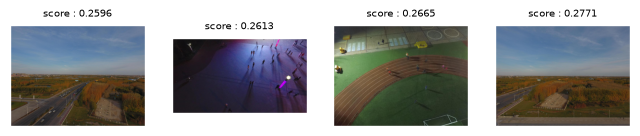

----------------------- dark images ------------------------

Number of examples with this issue: 15
Examples representing most severe instances of this issue:



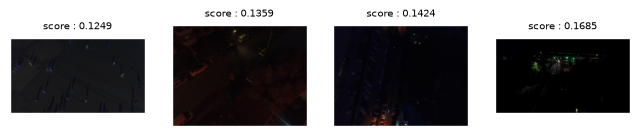

----------------- exact_duplicates images ------------------

Number of examples with this issue: 4
Examples representing most severe instances of this issue:

Set: 0


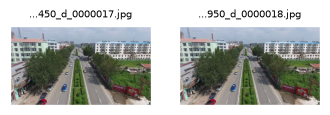

Set: 1


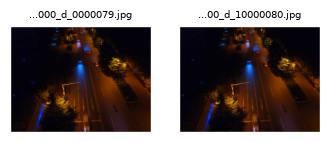

------------------ near_duplicates images ------------------

Number of examples with this issue: 2
Examples representing most severe instances of this issue:

Set: 0


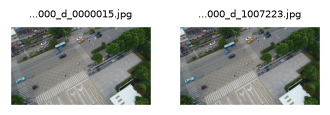

Reading images from /home/stiro/hobby/CV/Edge-Vehicle-Detection-and-Tracking/data/VisDrone2019-DET-val
Checking for dark, light, odd_aspect_ratio, low_information, exact_duplicates, near_duplicates, blurry, grayscale, odd_size images ...


Computing hashes: 100%|██████████| 548/548 [00:01<00:00, 415.17it/s]


Issue checks completed. 143 issues found in the dataset. To see a detailed report of issues found, use imagelab.report().
Issues found in images in order of severity in the dataset

|    | issue_type       |   num_images |
|---:|:-----------------|-------------:|
|  0 | odd_size         |          140 |
|  1 | exact_duplicates |            2 |
|  2 | dark             |            1 |
|  3 | light            |            0 |
|  4 | odd_aspect_ratio |            0 |
|  5 | blurry           |            0 |
|  6 | low_information  |            0 |
|  7 | grayscale        |            0 |
|  8 | near_duplicates  |            0 | 

--------------------- odd_size images ----------------------

Number of examples with this issue: 140
Examples representing most severe instances of this issue:



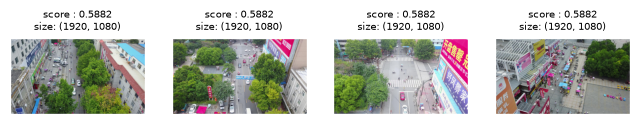

----------------- exact_duplicates images ------------------

Number of examples with this issue: 2
Examples representing most severe instances of this issue:

Set: 0


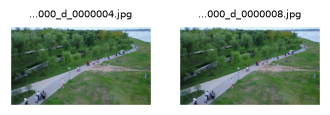

----------------------- dark images ------------------------

Number of examples with this issue: 1
Examples representing most severe instances of this issue:



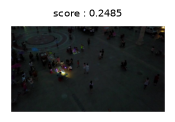

In [11]:
from cleanvision import Imagelab

inspection_results = []

for data_file in DATA_DIR.iterdir():
    imagelab = Imagelab(data_path=str(data_file))
    imagelab.find_issues()
    imagelab.report()
    inspection_results.append(imagelab)


In [50]:
for image_lab in inspection_results:
    for issue in image_lab.issues.iterrows():
        os.remove(issue[0])
        logging.debug(f"{issue[0]} was removed.")

In [12]:
out_of_boundaries_images = []

for split_dir in split_dirs:
    split_name = split_dir.name
    image_dir = split_dir / "images"

    for label_path in sorted((split_dir / "labels").glob("*.txt")):
        image_path = image_dir / f"{label_path.stem}.jpg"
        image_width, image_height = get_image_size(image_path)

        for _, x_0, y_0, width, height in iter_label_rows(label_path):
            if (x_0 + width) > image_width or (y_0 + height) > image_height:
                out_of_boundaries_images.append(image_path)


In [13]:
print(out_of_boundaries_images)


[]


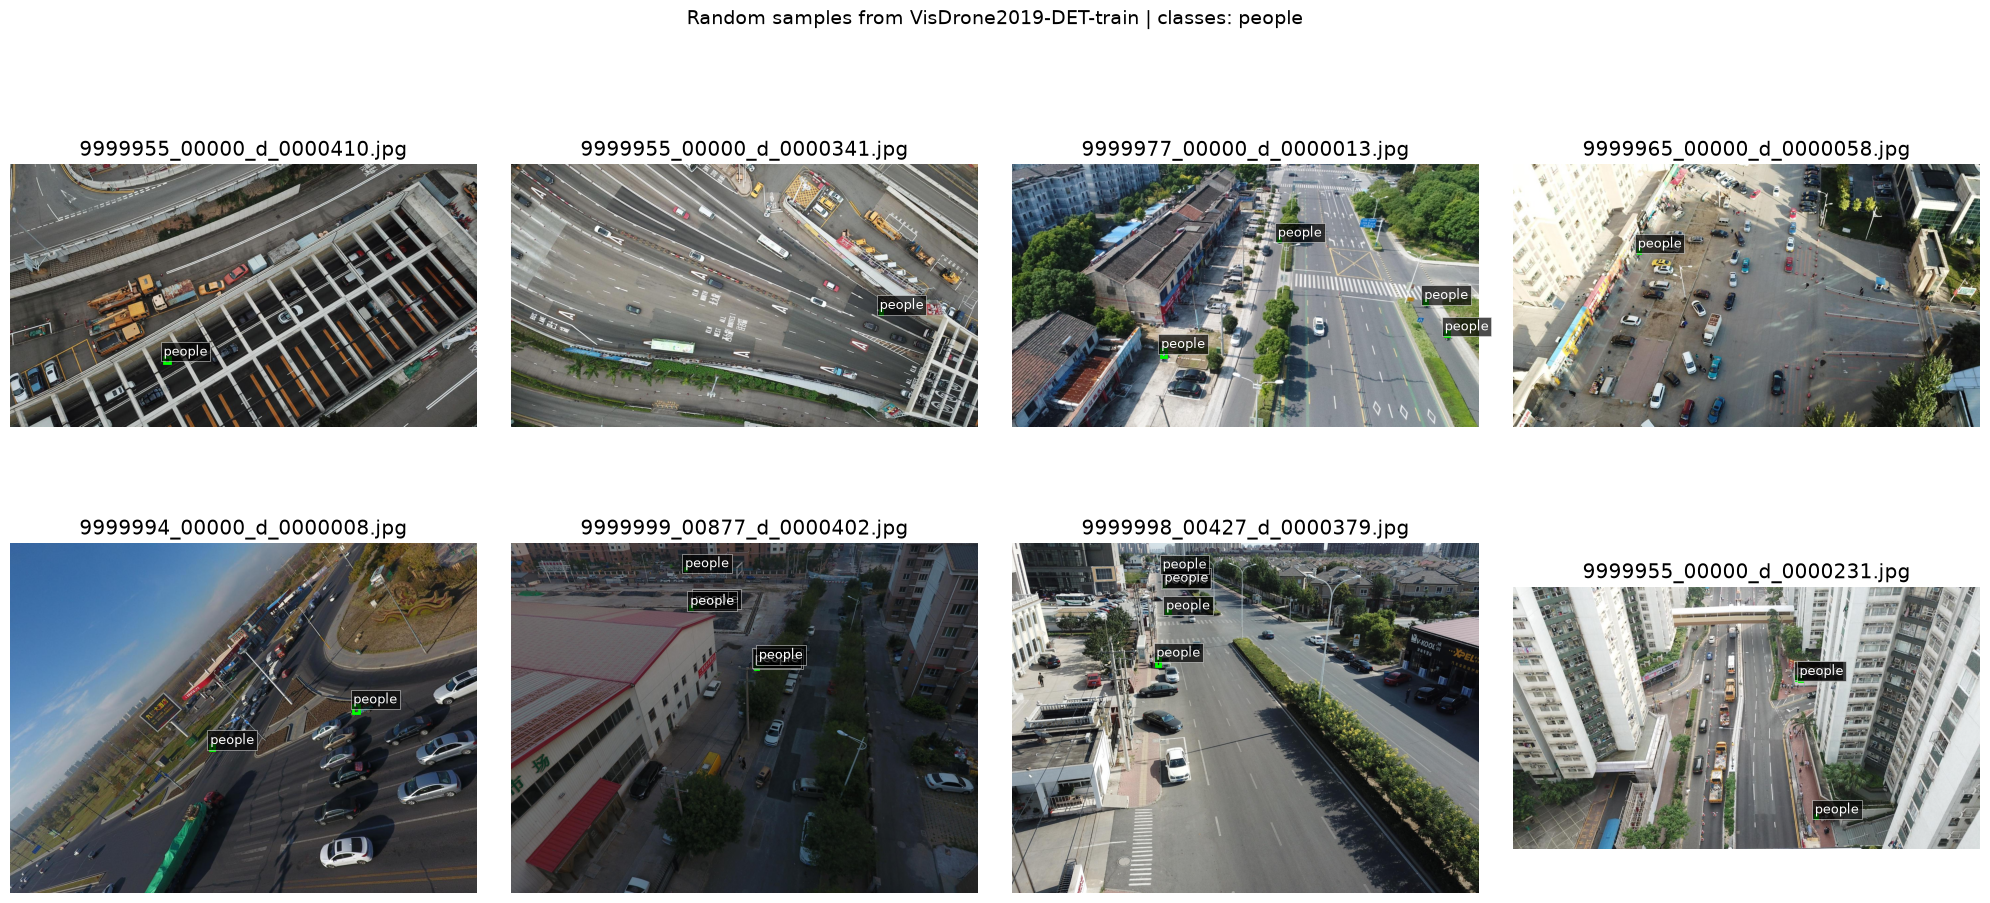

In [14]:
visualize_random_samples(DATA_DIR / "VisDrone2019-DET-train", values=[2])